<a href="https://colab.research.google.com/github/wesleymelodev/golden-ratio-deep-learning/blob/main/non-euclidean-golden-ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install geoopt

In [5]:
# --- Bloco 0: Preparação de Dados (Executar ANTES dos modelos) ---
from torchvision import datasets, transforms
import torch

# Transformação padrão MNIST (Mesma do seu estudo V1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carregamento dos Datasets
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Definição dos Loaders (Aqui corrigimos o NameError)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

print("Dados carregados com sucesso. 'train_loader' e 'test_loader' prontos.")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]

Dados carregados com sucesso. 'train_loader' e 'test_loader' prontos.


In [6]:
# --- Bloco 1: Arquitetura Hiperbólica + Phi (Estudo V2) ---
import torch
import torch.nn as nn
import geoopt
import math
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms

# Constantes Áureas
phi = (1 + math.sqrt(5)) / 2
phi_inv = 1 / phi
curvature = phi_inv

manifold = geoopt.PoincareBall(c=curvature)

class HyperGoldenMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10):
        super().__init__()
        self.manifold = manifold
        std = phi / math.sqrt(input_dim)

        self.weight = geoopt.ManifoldParameter(
            manifold.random_normal((hidden_dim, input_dim), std=std),
            manifold=manifold
        )
        self.bias = geoopt.ManifoldParameter(torch.zeros(hidden_dim), manifold=manifold)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x_hyp = self.manifold.expmap0(x)
        res = self.manifold.mobius_matvec(self.weight, x_hyp)
        res = self.manifold.mobius_add(res, self.bias)
        res = torch.nn.functional.relu(self.manifold.logmap0(res))
        return self.output_layer(res)

# Setup de Treino Hiperbólico
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_hyp = HyperGoldenMLP().to(device)
optimizer_hyp = geoopt.optim.RiemannianAdam(model_hyp.parameters(), lr=0.01 * phi_inv)
criterion = nn.CrossEntropyLoss()

train_losses_hyp = []
test_accuracies_hyp = []

# Loop de Treino V2
for epoch in range(10):
    model_hyp.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_hyp.zero_grad()
        outputs = model_hyp(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_hyp.step()
        running_loss += loss.item()

    model_hyp.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_hyp(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    loss_avg = running_loss / len(train_loader)
    train_losses_hyp.append(loss_avg)
    test_accuracies_hyp.append(acc)
    print(f"[Hiperbólico] Época {epoch+1}: Loss = {loss_avg:.4f}, Acc = {acc:.2f}%")

[Hiperbólico] Época 1: Loss = 0.4919, Acc = 91.41%
[Hiperbólico] Época 2: Loss = 0.2212, Acc = 95.10%
[Hiperbólico] Época 3: Loss = 0.1478, Acc = 96.28%
[Hiperbólico] Época 4: Loss = 0.1084, Acc = 96.77%
[Hiperbólico] Época 5: Loss = 0.0892, Acc = 96.96%
[Hiperbólico] Época 6: Loss = 0.0748, Acc = 97.46%
[Hiperbólico] Época 7: Loss = 0.0641, Acc = 97.57%
[Hiperbólico] Época 8: Loss = 0.0555, Acc = 97.62%
[Hiperbólico] Época 9: Loss = 0.0500, Acc = 97.49%
[Hiperbólico] Época 10: Loss = 0.0433, Acc = 97.70%


In [7]:
# --- Bloco 2: Arquitetura Esférica + Phi (Estudo V2) ---

# A geometria esférica usa uma curvatura positiva (+)
manifold_sph = geoopt.Stereographic(k=curvature)

class SphericalGoldenMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10):
        super().__init__()
        self.manifold = manifold_sph
        std = phi / math.sqrt(input_dim)

        # Parâmetros na Hipersfera
        self.weight = geoopt.ManifoldParameter(
            self.manifold.random_normal((hidden_dim, input_dim), std=std),
            manifold=self.manifold
        )
        self.bias = geoopt.ManifoldParameter(torch.zeros(hidden_dim), manifold=self.manifold)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        # Projeção para o espaço esférico
        x_sph = self.manifold.expmap0(x)
        # Operações de Möbius no espaço de curvatura positiva
        res = self.manifold.mobius_matvec(self.weight, x_sph)
        res = self.manifold.mobius_add(res, self.bias)
        res = torch.nn.functional.relu(self.manifold.logmap0(res))
        return self.output_layer(res)

# Setup de Treino Esférico
model_sph = SphericalGoldenMLP().to(device)
optimizer_sph = geoopt.optim.RiemannianAdam(model_sph.parameters(), lr=0.01 * phi_inv)

train_losses_sph = []
test_accuracies_sph = []

print(f"Iniciando treinamento V2 - Geometria Esférica (c=+{curvature:.4f})")

for epoch in range(10):
    model_sph.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_sph.zero_grad()
        outputs = model_sph(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_sph.step()
        running_loss += loss.item()

    model_sph.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_sph(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc_sph = 100 * correct / total
    loss_sph = running_loss / len(train_loader)
    train_losses_sph.append(loss_sph)
    test_accuracies_sph.append(acc_sph)
    print(f"[Esférico] Época {epoch+1}: Loss = {loss_sph:.4f}, Acc = {acc_sph:.2f}%")

Iniciando treinamento V2 - Geometria Esférica (c=+0.6180)
[Esférico] Época 1: Loss = 0.6316, Acc = 91.13%
[Esférico] Época 2: Loss = 0.2903, Acc = 93.37%
[Esférico] Época 3: Loss = 0.2269, Acc = 94.42%
[Esférico] Época 4: Loss = 0.1872, Acc = 95.05%
[Esférico] Época 5: Loss = 0.1586, Acc = 96.04%
[Esférico] Época 6: Loss = 0.1367, Acc = 96.29%
[Esférico] Época 7: Loss = 0.1211, Acc = 96.48%
[Esférico] Época 8: Loss = 0.1068, Acc = 96.40%
[Esférico] Época 9: Loss = 0.0967, Acc = 97.00%
[Esférico] Época 10: Loss = 0.0877, Acc = 96.82%


In [8]:
# --- Bloco 3: Arquitetura Tradicional (Controle - Xavier/Euclidiano) ---

class StandardMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(p=0.5) # Padrão de mercado (Xavier costuma usar 0.5)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.apply(self._init_weights)

    def _init_weights(self, layer):
        if isinstance(layer, nn.Linear):
            # Inicialização Xavier Normal (Padrão de Mercado)
            nn.init.xavier_normal_(layer.weight)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Configuração de treino do Controle
model_std = StandardMLP().to(device)
optimizer_std = torch.optim.Adam(model_std.parameters(), lr=0.01)
# Scheduler padrão para comparação
scheduler_std = torch.optim.lr_scheduler.StepLR(optimizer_std, step_size=5, gamma=0.5)

train_losses_std = []
test_accuracies_std = []

print(f"Iniciando treinamento de controle - Arquitetura Euclidiana (Xavier)")

for epoch in range(10):
    model_std.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_std.zero_grad()
        outputs = model_std(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_std.step()
        running_loss += loss.item()

    scheduler_std.step()

    # Avaliação do Controle
    model_std.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_std(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc_std = 100 * correct / total
    loss_std = running_loss / len(train_loader)
    train_losses_std.append(loss_std)
    test_accuracies_std.append(acc_std)
    print(f"[Xavier] Época {epoch+1}: Loss = {loss_std:.4f}, Acc = {acc_std:.2f}%")

Iniciando treinamento de controle - Arquitetura Euclidiana (Xavier)
[Xavier] Época 1: Loss = 0.9952, Acc = 87.72%
[Xavier] Época 2: Loss = 0.8511, Acc = 89.59%
[Xavier] Época 3: Loss = 0.8325, Acc = 89.55%
[Xavier] Época 4: Loss = 0.8863, Acc = 90.28%
[Xavier] Época 5: Loss = 0.8569, Acc = 90.10%
[Xavier] Época 6: Loss = 0.7023, Acc = 91.96%
[Xavier] Época 7: Loss = 0.6912, Acc = 91.86%
[Xavier] Época 8: Loss = 0.6875, Acc = 91.50%
[Xavier] Época 9: Loss = 0.6766, Acc = 91.29%
[Xavier] Época 10: Loss = 0.6795, Acc = 92.06%


Mounted at /content/drive
Google Drive conectado com sucesso.


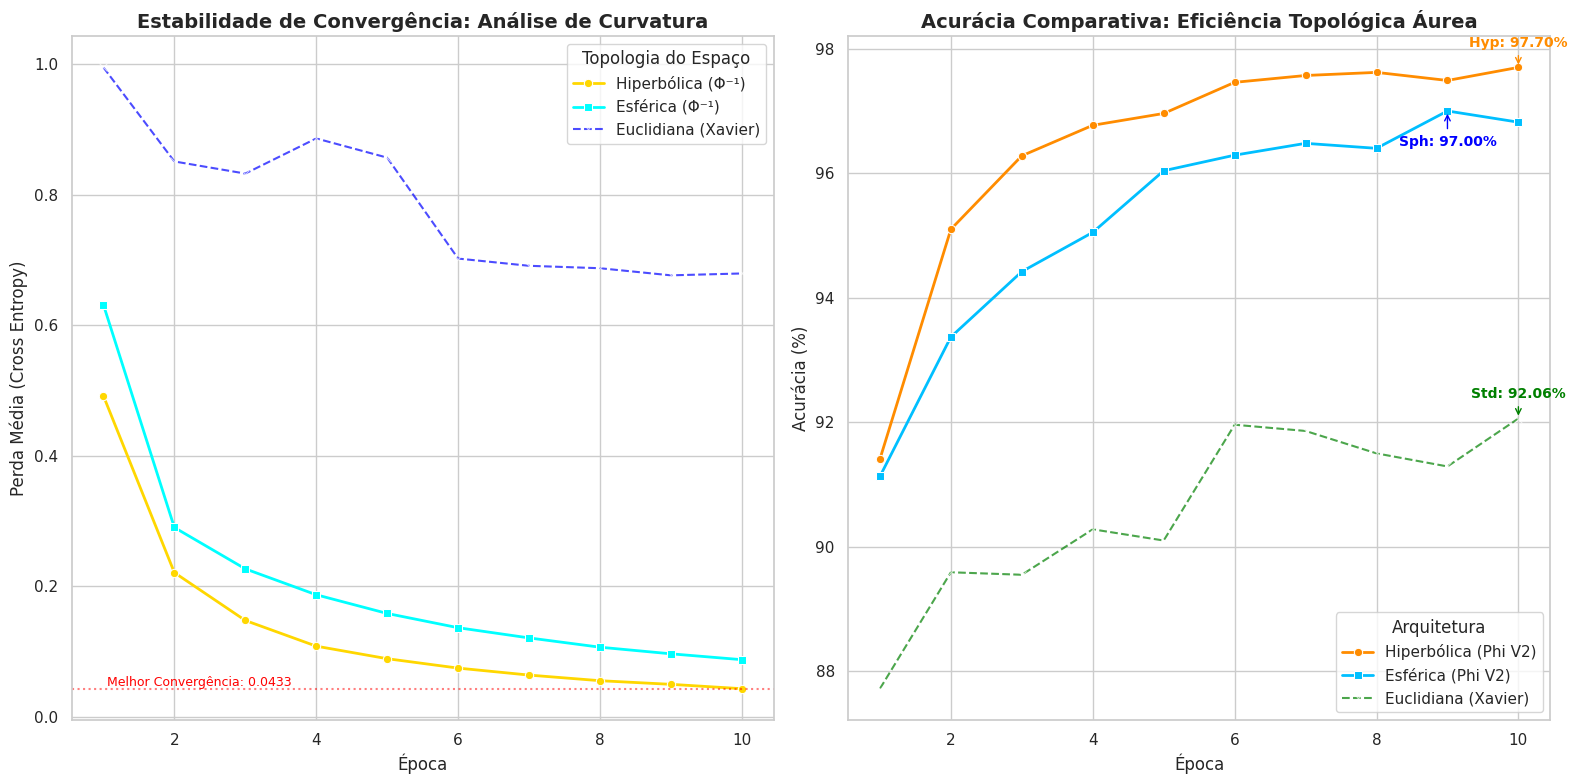

Relatório visual gerado com sucesso em: /content/drive/MyDrive/ESTUDO_CIENTIFICO_V2_TOTAL_2026-06-01_00-04-42.png


In [10]:
# --- Bloco 4: Gráfico Comparativo Total Profissional (V2: Curvatura vs Euclidiano) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from google.colab import drive
import os

# 1. Montar o Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Verificar se a pasta MyDrive está acessível
if os.path.exists('/content/drive/MyDrive'):
    print("Google Drive conectado com sucesso.")
else:
    print("Erro: Não foi possível acessar o MyDrive. Verifique a montagem.")

# Definindo estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

# 1. Gráfico de Perda (Loss Convergence)
plt.subplot(1, 2, 1)
epochs = range(1, 11)

# Plotagem das três linhas
sns.lineplot(x=epochs, y=train_losses_hyp, marker='o', color='gold', label='Hiperbólica (Φ⁻¹)', linewidth=2)
sns.lineplot(x=epochs, y=train_losses_sph, marker='s', color='cyan', label='Esférica (Φ⁻¹)', linewidth=2)
sns.lineplot(x=epochs, y=train_losses_std, marker='x', color='blue', label='Euclidiana (Xavier)', linestyle='--', alpha=0.7)

plt.title('Estabilidade de Convergência: Análise de Curvatura', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Perda Média (Cross Entropy)')
plt.legend(title="Topologia do Espaço")

# Anotação Inteligente: Menor Perda Geral
all_losses = [train_losses_hyp[-1], train_losses_sph[-1], train_losses_std[-1]]
best_loss = min(all_losses)
plt.axhline(y=best_loss, color='red', linestyle=':', alpha=0.5)
plt.text(1, best_loss, f' Melhor Convergência: {best_loss:.4f}', color='red', va='bottom', fontsize=9)

# 2. Gráfico de Acurácia (Accuracy Evolution)
plt.subplot(1, 2, 2)

sns.lineplot(x=epochs, y=test_accuracies_hyp, marker='o', color='darkorange', label='Hiperbólica (Phi V2)', linewidth=2)
sns.lineplot(x=epochs, y=test_accuracies_sph, marker='s', color='deepskyblue', label='Esférica (Phi V2)', linewidth=2)
sns.lineplot(x=epochs, y=test_accuracies_std, marker='x', color='green', label='Euclidiana (Xavier)', linestyle='--', alpha=0.7)

plt.title('Acurácia Comparativa: Eficiência Topológica Áurea', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend(title="Arquitetura")

# Anotações de Pico de Performance
def annotate_max(data, label, color, offset):
    ymax = np.max(data)
    xpos = np.argmax(data) + 1
    plt.annotate(f'{label}: {ymax:.2f}%',
                 xy=(xpos, ymax),
                 xytext=(0, offset),
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color=color),
                 color=color, fontweight='bold', fontsize=10, ha='center')

# Aplicando anotações sem sobreposição
annotate_max(test_accuracies_hyp, 'Hyp', 'darkorange', 15)
annotate_max(test_accuracies_sph, 'Sph', 'blue', -25)
annotate_max(test_accuracies_std, 'Std', 'green', 15)

plt.tight_layout()

# Exibição e Salvamento Profissional
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_path = f'/content/drive/MyDrive/ESTUDO_CIENTIFICO_V2_TOTAL_{timestamp}.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Relatório visual gerado com sucesso em: {save_path}")